In [ ]:
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
import matplotlib.pyplot as plt

# 1. DATA PREPARATION
data_dir = "images_original"

filepaths = []
labels = []

# Read all images
for genre in os.listdir(data_dir):
    genre_path = os.path.join(data_dir, genre)
    
    if os.path.isdir(genre_path):
        for img in os.listdir(genre_path):
            filepaths.append(os.path.join(genre_path, img))
            labels.append(genre)

df = pd.DataFrame({
    "filename": filepaths,
    "class": labels
})

# 70% train, 30% temp
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["class"],
    random_state=42
)

# 15% validation, 15% test
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["class"],
    random_state=42
)

# MobileNetV2 expects pixels between -1 and 1, NOT 0 and 1.
# We replace rescale=1./255 with its specific preprocess_input function.
datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Train data
train_data = datagen.flow_from_dataframe(
    train_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

# Validation data
val_data = datagen.flow_from_dataframe(
    val_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical"
)

# Test data
test_data = datagen.flow_from_dataframe(
    test_df,
    x_col="filename",
    y_col="class",
    target_size=(128,128),
    batch_size=32,
    class_mode="categorical",
    shuffle=False
)


Found 699 validated image filenames belonging to 10 classes.
Found 150 validated image filenames belonging to 10 classes.
Found 150 validated image filenames belonging to 10 classes.


In [ ]:

# Load the pre-trained MobileNetV2 model without the final classification layers
base_model = MobileNetV2(
    input_shape=(128, 128, 3), 
    include_top=False, 
    weights='imagenet' 
)

base_model.trainable = False


cnn = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile Model
cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:

early_stop = EarlyStopping(
    monitor='val_accuracy', 
    patience=10, 
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_mobilenet_cnn.keras', 
    monitor='val_accuracy', 
    save_best_only=True
)

history = cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=50, 
    callbacks=[early_stop, checkpoint]
)


Epoch 1/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 268ms/step - accuracy: 0.7024 - loss: 0.8433 - val_accuracy: 0.6400 - val_loss: 1.0197
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 215ms/step - accuracy: 0.7482 - loss: 0.7805 - val_accuracy: 0.6467 - val_loss: 0.9617
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 181ms/step - accuracy: 0.7082 - loss: 0.8382 - val_accuracy: 0.6267 - val_loss: 1.0137
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.7539 - loss: 0.7623 - val_accuracy: 0.6600 - val_loss: 0.9706
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 178ms/step - accuracy: 0.7654 - loss: 0.7245 - val_accuracy: 0.6533 - val_loss: 0.9727
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step - accuracy: 0.7597 - loss: 0.6787 - val_accuracy: 0.6533 - val_loss: 0.9671
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 174ms/step - accuracy: 0.7740 - loss: 0.6461 - val_accuracy: 0.6400 - val_loss: 0.9886
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 4s 177ms/step - accuracy: 0.7840 - loss: 0.6290 - val_accuracy: 0.

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 123ms/step - accuracy: 0.5933 - loss: 1.1108

Final Test Accuracy: 0.5933


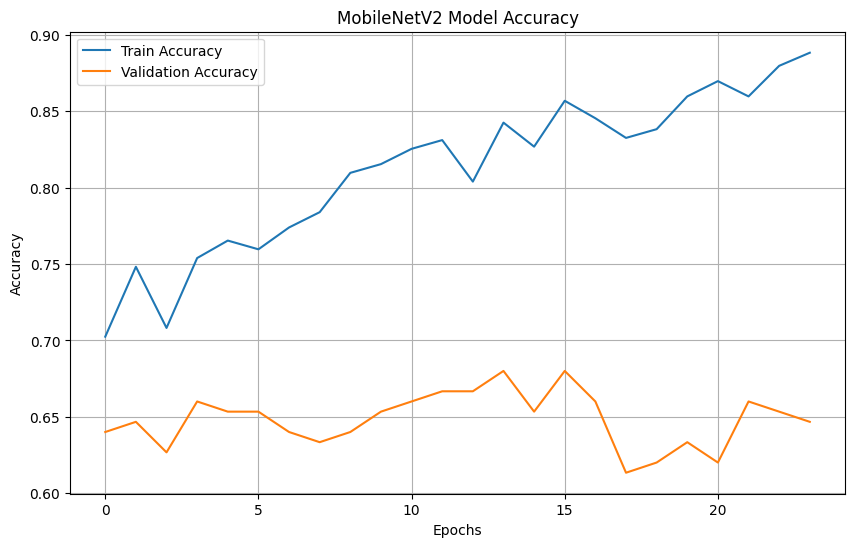

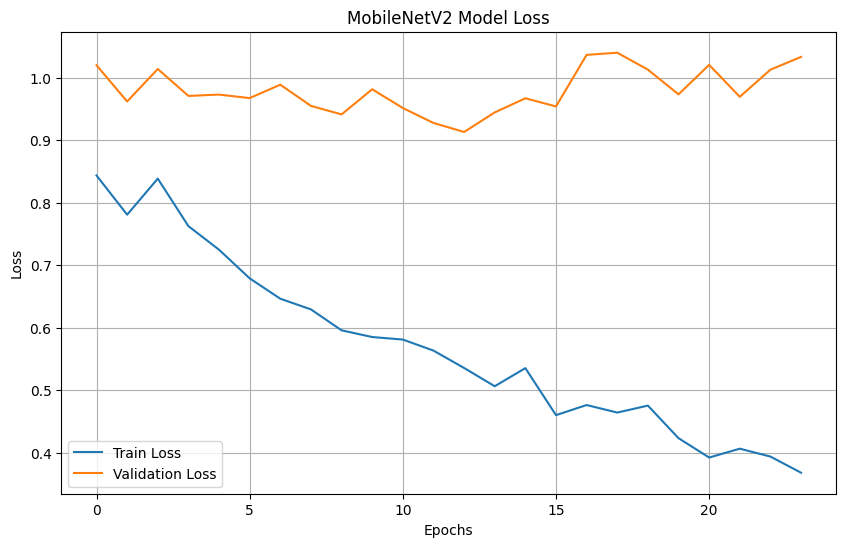

In [ ]:

test_loss, test_acc = cnn.evaluate(test_data)
print(f"\nFinal Test Accuracy: {test_acc:.4f}")

# Accuracy Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('MobileNetV2 Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Loss Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('MobileNetV2 Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


In [1]:
cnn.save("music_genre_transfer_learning.h5")

print("Model saved successfully as music_genre_transfer_learning.h5")

NameError: name 'cnn' is not defined